# Factor Bar Chart and Timeseries Figures

In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [2]:
# force the math text to look normal
mpl.rcParams['mathtext.default'] = 'regular'

def major_ticks(x, pos=None):
    """Set the major ticks according
    to this custom style
    """
    x = mdates.num2date(x)
    if pos == 0:
        fmt = "%-d\n%b %Y\n%I %p"
    else:
        fmt = "%-d"
    return x.strftime(fmt)

# set the default seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
#load in the comp data
comp = pd.read_csv('679_factor_resid.csv')
comp.rename(columns={'Unnamed: 0':'species'},inplace=True)
comp

,species,Factor 1,Factor 2,Factor 3,Factor 4,Residual
0,co,0.548439,0.103401,0.028498,0.298511,0.021152
1,no,0.527478,0.061018,0.024717,0.364778,0.022009
2,no2,0.967458,0.021862,0.014467,0.000341,-0.004128
3,o3,0.338161,0.028558,0.000000,0.639100,-0.005819
4,bin0,0.015348,0.757453,0.000000,0.242368,-0.015169
5,bin1,0.000000,0.795658,0.314690,0.000000,-0.110348
6,bin2,0.000000,0.509958,0.586811,0.000000,-0.096769
7,bin3,0.000000,0.272692,0.749940,0.000000,-0.022632
8,bin4,0.043533,0.056883,0.757134,0.151444,-0.008994
9,bin5,0.092330,0.000000,0.606213,0.305401,-0.003944


In [4]:
comp2 = pd.melt(comp,id_vars='species', value_vars=['Factor 1','Factor 2','Residual'])
comp2

,species,variable,value
0,co,Factor 1,0.548439
1,no,Factor 1,0.527478
2,no2,Factor 1,0.967458
3,o3,Factor 1,0.338161
4,bin0,Factor 1,0.015348
5,bin1,Factor 1,0.000000
6,bin2,Factor 1,0.000000
7,bin3,Factor 1,0.000000
8,bin4,Factor 1,0.043533
9,bin5,Factor 1,0.092330


In [10]:
#load in the timeseries data
ts = pd.read_csv('MOD-000679_timeseries_hourly_scaled.csv').reset_index()
results = pd.read_csv('679_factor_results.csv')

ts = pd.concat([ts,results['Factor 1'],results['Factor 2'],results['Factor 3']], axis = 1)
cols_reordered = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','co','o3','no','no2','Factor 1','Factor 2']
ts = ts[cols_reordered]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2
0,2025-04-25 13:00:00,0.087923,0.031390,0.025307,0.025229,0.040000,0.065217,0.536301,0.833295,0.082859,0.147252,0.018333,0.008988
1,2025-04-25 14:00:00,0.084015,0.034006,0.029646,0.029817,0.045714,0.072464,0.485643,0.807340,0.231922,0.144918,0.017326,0.006995
2,2025-04-25 15:00:00,0.075223,0.034006,0.029646,0.029817,0.045714,0.072464,0.432164,0.779899,0.084108,0.191598,0.020806,0.003784
3,2025-04-25 16:00:00,0.059836,0.028774,0.028200,0.032110,0.048571,0.072464,0.409734,0.740567,0.060375,0.253554,0.026801,0.000252
4,2025-04-25 17:00:00,0.071315,0.046338,0.033261,0.032110,0.048571,0.065217,0.385837,0.730391,0.055656,0.321239,0.032730,0.003485


In [11]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local']) #convert timestamp column to pandas timestamp format
ts = ts.set_index('timestamp_local',append=False) #setindex as local time
ts

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2
timestamp_local,,,,,,,,,,,,
2025-04-25 13:00:00,0.087923,0.031390,0.025307,0.025229,0.040000,0.065217,0.536301,0.833295,0.082859,0.147252,0.018333,0.008988
2025-04-25 14:00:00,0.084015,0.034006,0.029646,0.029817,0.045714,0.072464,0.485643,0.807340,0.231922,0.144918,0.017326,0.006995
2025-04-25 15:00:00,0.075223,0.034006,0.029646,0.029817,0.045714,0.072464,0.432164,0.779899,0.084108,0.191598,0.020806,0.003784
2025-04-25 16:00:00,0.059836,0.028774,0.028200,0.032110,0.048571,0.072464,0.409734,0.740567,0.060375,0.253554,0.026801,0.000252
2025-04-25 17:00:00,0.071315,0.046338,0.033261,0.032110,0.048571,0.065217,0.385837,0.730391,0.055656,0.321239,0.032730,0.003485
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 14:00:00,0.070460,0.020553,0.012292,0.011468,0.008571,0.007246,0.303950,0.392065,0.027203,0.621260,0.063563,0.010785
2025-12-31 15:00:00,0.064110,0.022048,0.012292,0.009174,0.011429,0.007246,0.306438,0.384862,0.025399,0.634628,0.065051,0.009986
2025-12-31 16:00:00,0.071071,0.023543,0.014461,0.011468,0.011429,0.014493,0.318312,0.375486,0.032616,0.635689,0.065293,0.012092


In [12]:
#taking daily average of ts. round to floor of the day
ts = ts.reset_index()

ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  factor1 = ('Factor 1','mean'),
                                                  factor2 = ('Factor 2','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,factor1,factor2
timestamp_local,,,,,,,,,,,,
2025-04-25,0.068185,0.034719,0.032012,0.037740,0.062078,0.109354,0.418210,0.698678,0.066292,0.343151,0.035320,0.002660
2025-04-26,0.188418,0.075206,0.049349,0.057339,0.101786,0.196860,0.340895,0.487875,0.028938,0.365947,0.033978,0.029562
2025-04-27,0.012607,0.005570,0.003925,0.003823,0.004354,0.007591,0.285897,0.578060,0.029318,0.314409,0.032559,0.000000
2025-04-28,0.031933,0.014979,0.010665,0.009365,0.012143,0.019022,0.333031,0.613061,0.032599,0.292109,0.030903,0.001503
2025-04-29,0.055634,0.031484,0.029977,0.031919,0.042500,0.062500,0.360980,0.593762,0.033796,0.439980,0.044969,0.003001


## Setting Up Barchart and 6-month Figures

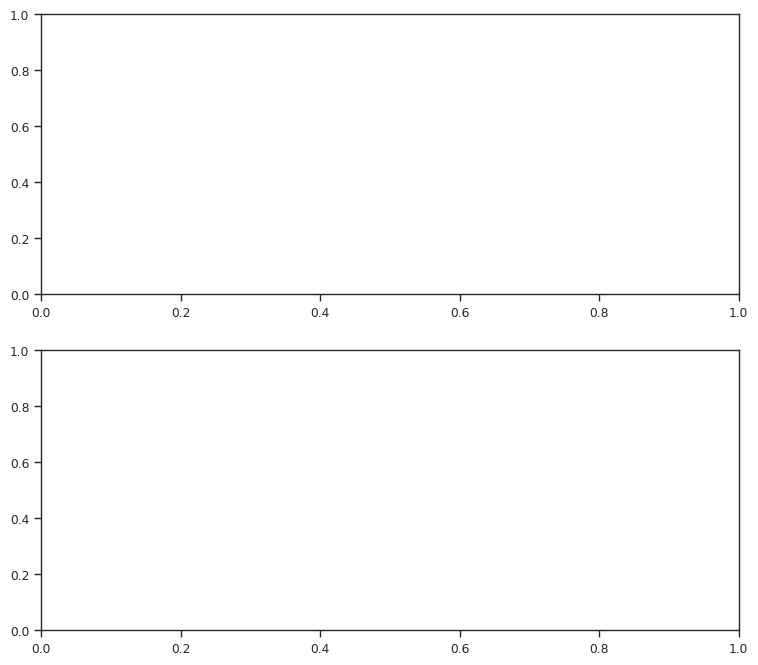

In [13]:
# set up the figure
fig = plt.figure(figsize=(9, 8))

ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

In [14]:
cols = ['bin0', 'bin1', 'bin2','bin3','bin4','bin5','co', 'o3','no', 'no2']

pal = sns.color_palette()

colors = [pal[3], pal[2], pal[4], pal[5]]
colors += sns.color_palette("Blues", 6)
colors.reverse()

In [15]:
ax1 = sns.barplot(x='variable',y='value',
        data=comp2,
        ax=ax1, hue='species',hue_order=cols,
        palette=colors, saturation=1, edgecolor='black', linewidth=0.25,
        errwidth=.75)

/tmp/ipykernel_758/2976516543.py:1: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  ax1 = sns.barplot(x='variable',y='value',


In [16]:
ax1.set_ylim(-0.2, 1)
ax1.set_xlabel("")
ax1.set_ylabel("Percent of Species Signal\nDescribed by Factor", fontsize=14)
ax1.set(yticks=np.linspace(-0.2, 1, 13), yticklabels=["","","0","","","","","50","","","","","100"])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(y=0, color='black', linestyle='-', lw =0.5)

In [17]:
handles, _ = ax1.get_legend_handles_labels()
labels = ["Bin 0", "Bin 1", "Bin 2", "Bin 3","Bin 4","Bin 5","CO","$O_3$","$NO$", "$NO_2$"]
ax1.legend(handles, labels)

In [18]:
ax2.plot(ts_day.index, ts_day["factor1"], label="Factor 1 ", lw=1, color=sns.xkcd_rgb['slate blue'])
ax2.plot(ts_day.index, ts_day["factor2"], label="Factor 2", lw=1, color=sns.xkcd_rgb['dull green'])

ax2.set_ylabel("Factor Intensity (a.u.)", fontsize=14)

#last 6 months
ax2.set_xlim(ts_day.index[-180], ts_day.index[-1])
#ax2.set_xlim(ts_day.index[0], ts_day.index[-1])

ax2.legend(loc='upper right',fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=14)

In [19]:
ax1.set_title('(a)',fontsize=14)
ax2.set_title('(b)',fontsize=14)

Text(0.5, 1.0, '(b)')

In [20]:
plt.gcf().text(0.09, 0.9, "(a)", fontsize=12)
plt.gcf().text(0.5, 0.9, "(b)", fontsize=12)
plt.gcf().text(0.09,0.9,'MOD-00397',fontsize=12)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [21]:
import os

# Create the directory if it doesn't exist
os.makedirs('MOD-00679', exist_ok=True)

fig.savefig('MOD-00679/time_barchart_MOD-000679_2_factor.png')

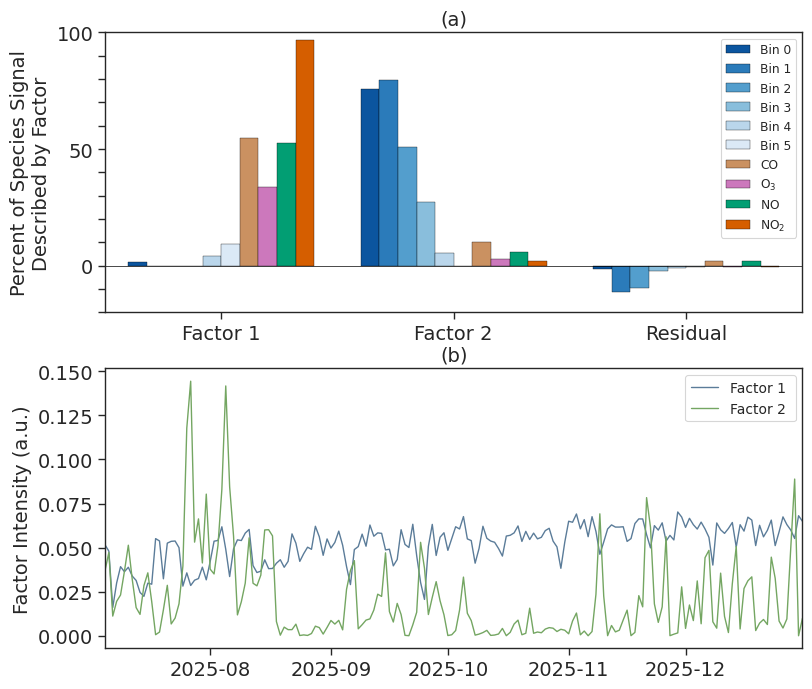

In [22]:
fig

## Setting Up Diurnal Figure

In [23]:
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2
0,2025-04-25 13:00:00,0.087923,0.031390,0.025307,0.025229,0.040000,0.065217,0.536301,0.833295,0.082859,0.147252,0.018333,0.008988
1,2025-04-25 14:00:00,0.084015,0.034006,0.029646,0.029817,0.045714,0.072464,0.485643,0.807340,0.231922,0.144918,0.017326,0.006995
2,2025-04-25 15:00:00,0.075223,0.034006,0.029646,0.029817,0.045714,0.072464,0.432164,0.779899,0.084108,0.191598,0.020806,0.003784
3,2025-04-25 16:00:00,0.059836,0.028774,0.028200,0.032110,0.048571,0.072464,0.409734,0.740567,0.060375,0.253554,0.026801,0.000252
4,2025-04-25 17:00:00,0.071315,0.046338,0.033261,0.032110,0.048571,0.065217,0.385837,0.730391,0.055656,0.321239,0.032730,0.003485


In [24]:
#prepping data
ts = ts.set_index('timestamp_local')
ts['Hour'] = ts.index.hour
ts.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Hour
timestamp_local,,,,,,,,,,,,,
2025-04-25 13:00:00,0.087923,0.031390,0.025307,0.025229,0.040000,0.065217,0.536301,0.833295,0.082859,0.147252,0.018333,0.008988,13
2025-04-25 14:00:00,0.084015,0.034006,0.029646,0.029817,0.045714,0.072464,0.485643,0.807340,0.231922,0.144918,0.017326,0.006995,14
2025-04-25 15:00:00,0.075223,0.034006,0.029646,0.029817,0.045714,0.072464,0.432164,0.779899,0.084108,0.191598,0.020806,0.003784,15
2025-04-25 16:00:00,0.059836,0.028774,0.028200,0.032110,0.048571,0.072464,0.409734,0.740567,0.060375,0.253554,0.026801,0.000252,16
2025-04-25 17:00:00,0.071315,0.046338,0.033261,0.032110,0.048571,0.065217,0.385837,0.730391,0.055656,0.321239,0.032730,0.003485,17


In [25]:
#grouping by hour and calculate the mean
diurnal_data = ts.groupby('Hour')[['Factor 1','Factor 2']].mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,Factor 1,Factor 2
Hour,,
00:00,0.051461,0.026153
01:00,0.051439,0.025846
02:00,0.051882,0.025695
03:00,0.050545,0.026241
04:00,0.050152,0.027206
05:00,0.050715,0.028538
06:00,0.052291,0.028522
07:00,0.050097,0.028216
08:00,0.043809,0.026955


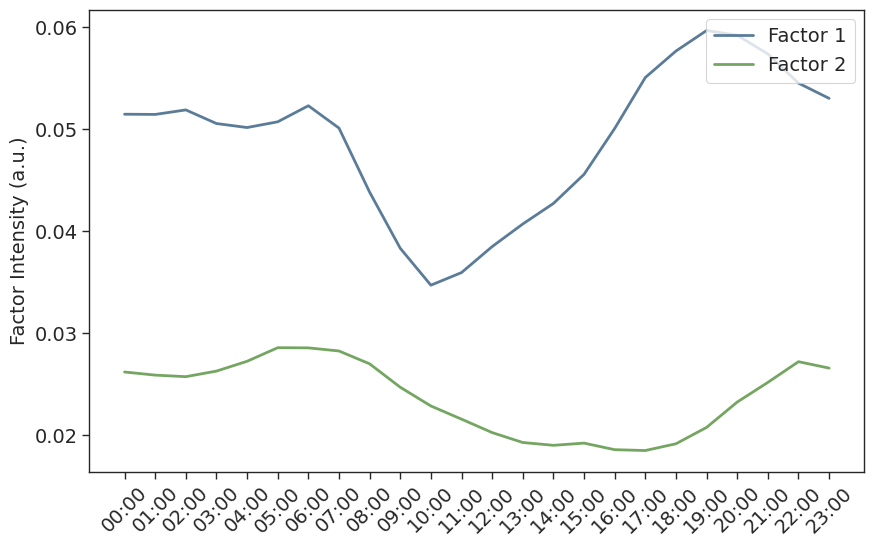

In [27]:
# set up the figure
plt.figure(figsize=(10, 6))

plt.plot(diurnal_data.index, diurnal_data['Factor 1'], label='Factor 1', lw = 2, color=sns.xkcd_rgb['slate blue'])
plt.plot(diurnal_data.index, diurnal_data['Factor 2'], label='Factor 2', lw = 2, color=sns.xkcd_rgb['dull green'])

plt.ylabel('Factor Intensity (a.u.)', fontsize = 14)
plt.legend(loc='upper right',fontsize=14)
plt.xticks(range(0, 24))
plt.xticks(rotation=45)

plt.tick_params(labelsize=14)

plt.savefig('MOD-00679/diurnal_MOD-000679_2_factor.png')
plt.show()